In [ ]:
# COMP541 organized folder path helper
from pathlib import Path
import os

def _comp541_phase_dir():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == 'code':
        return cwd.parent
    if (cwd / 'Input').exists() and (cwd / 'Output').exists():
        return cwd
    if (cwd.parent / 'Input').exists() and (cwd.parent / 'Output').exists():
        return cwd.parent
    # Fallback for the intended layout: notebook/script is inside a Code folder.
    return cwd.parent if cwd.name.lower() == 'code' else cwd

PHASE_DIR = _comp541_phase_dir()
INPUT_DIR = PHASE_DIR / 'Input'
OUTPUT_DIR = PHASE_DIR / 'Output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('INPUT_DIR :', INPUT_DIR.resolve())
print('OUTPUT_DIR:', OUTPUT_DIR.resolve())


# **Data Pre-Processing (Part 2) — Feature Selection & Extraction**

*COMP 541 Data Mining · Group 1 · "Finding the Best Budget-Friendly Travel Destinations."*

Uses the team's original approach — variance + correlation filtering,
**Random-Forest feature selection** toward two targets,
and **PCA** on the cost and review blocks:

1. **Budget Value Index = cost + satisfaction + weather**, built on the
   **cost+weather pool (~105 cities)** so it clears the proposal's "≥50," instead of the
   ~64 the Airbnb-based version reached.
2. **No zero-penalty:** optional pieces (satisfaction, Airbnb) are folded in **only where
   present**.
3. **Flight Feature Creation** geocoding → `distance_from_lax_km` →
   a **distance-based airfare estimate** (with an `flight_price_estimated` flag), plus a
   `climate_zone`.
4. **Output columns** (cost, weather, `has_*` flags, geo features) so
   the Modeling phase can cluster and rank on them.
5. **`is_budget_friendly`** is defined on the pooled, proposal-aligned index.

#### **Imports & setup**

In [1]:
import os, re, unicodedata, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from pathlib import Path as _Path
import seaborn as sns

try:
    import geonamescache
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "geonamescache"])
    import geonamescache

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 150)
RANDOM_STATE = 42


def section(t):
    print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)

#### **Locate the Assignment-3 integrated files** (Colab auto-detect / local ascend)

In [2]:
# Organized folder paths
DATA_DIR = str(INPUT_DIR)
OUTPUT_DIR = str(OUTPUT_DIR)
CHART_DIR = OUTPUT_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR  :", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CHART_DIR :", CHART_DIR)


Mounted at /content/drive


FileNotFoundError: integrated_destinations_union.csv not found; set DATA_DIR manually.

#### **Helper functions** (join keys, scaling, distance, geocoder)

In [ ]:
def make_key(text, alias=None):
    if pd.isna(text):
        return np.nan
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[\"'{}]", "", text).lower()
    text = re.sub(r"[^a-z0-9 ]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return alias.get(text, text) if alias else text


def minmax(s):
    s = s.astype(float); rng = s.max() - s.min()
    return (s - s.min()) / rng if rng else s * 0.0


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    d = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(d))


LAX_LAT, LAX_LON = 33.9416, -118.4085
CITY_ALIASES = {"new york": "new york city", "antwerp": "antwerpen", "quebec city": "quebec"}
COUNTRY_ALIASES = {"the netherlands": "netherlands", "viet nam": "vietnam"}

_gc = geonamescache.GeonamesCache()
NAME2ISO = {make_key(c["name"]): c["iso"] for c in _gc.get_countries().values()}
NAME2ISO.update({"united states": "US", "south korea": "KR", "vietnam": "VN", "russia": "RU",
                 "czechia": "CZ", "united kingdom": "GB", "hong kong": "HK", "bolivia": "BO",
                 "venezuela": "VE", "tanzania": "TZ", "iran": "IR", "laos": "LA"})
CITY_INDEX = {}
for c in _gc.get_cities().values():
    for nm in [c["name"]] + c.get("alternatenames", []):
        k = make_key(nm)
        if k:
            CITY_INDEX.setdefault(k, []).append(c)


def geocode(city, country):
    ck = make_key(city, CITY_ALIASES); iso = NAME2ISO.get(make_key(country, COUNTRY_ALIASES))
    cand = CITY_INDEX.get(ck)
    if not cand:
        return pd.Series([np.nan, np.nan, "unmatched"])
    if iso:
        same = [c for c in cand if c["countrycode"] == iso]
        if same:
            c = max(same, key=lambda x: x["population"])
            return pd.Series([c["latitude"], c["longitude"], "city+country"])
    c = max(cand, key=lambda x: x["population"])
    return pd.Series([c["latitude"], c["longitude"], "city-only"])

**Visual Helpers**

In [ ]:

_CHART_PATH = _Path(CHART_DIR)   # CHART_DIR already set in env-setup cell


def save_visual(fig, filename):
    """Save figure to the chart folder."""
    path = _CHART_PATH / filename
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)
    return path


def first_existing(dataframe, candidates):
    """Return the first candidate column that exists in dataframe."""
    for col in candidates:
        if col in dataframe.columns:
            return col
    return None


def clean_label(value):
    if pd.isna(value):
        return "Unknown"
    return str(value).replace("_", " ").strip().title()


def minmax_score(series, higher_is_better=True):
    s = pd.to_numeric(series, errors="coerce")
    if s.notna().sum() == 0:
        return pd.Series(0.5, index=s.index)
    s = s.fillna(s.median())
    if s.nunique() <= 1:
        out = pd.Series(0.5, index=s.index)
    else:
        out = (s - s.min()) / (s.max() - s.min())
    return (1 - out) if not higher_is_better else out


def make_text_visual(title, message, filename):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=15)
    ax.text(0.5, 0.5, message, ha="center", va="center", fontsize=12, wrap=True)
    return save_visual(fig, filename)


def add_bar_labels(ax, orientation="vertical", fmt="{:.0f}"):
    if orientation == "horizontal":
        for bar in ax.patches:
            w = bar.get_width()
            ax.text(w + 0.15, bar.get_y() + bar.get_height() / 2,
                    fmt.format(w), va="center", ha="left", fontsize=9)
    else:
        for bar in ax.patches:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
                    fmt.format(h), va="bottom", ha="center", fontsize=9)





#### **A. Feature Creation — geocoding, distance from LAX, airfare estimate, climate**

We attach coordinates with the offline `geonamescache` gazetteer, compute the great-circle distance from LAX,
then **estimate one-way airfare from distance** (log–log model trained on the 49 real quotes, validated
with leave-one-out) for every city and flags which fares are estimates. We also derive a
`climate_zone` from latitude.

In [ ]:
df[["lat", "lon", "geocode_source"]] = df.apply(lambda r: geocode(r["city"], r["country"]), axis=1)
df["distance_from_lax_km"] = haversine_km(df["lat"], df["lon"], LAX_LAT, LAX_LON)
section("GEOCODING + DISTANCE")
print("match rate:", f"{df['lat'].notna().mean():.1%}", "of", len(df))

# Distance-based airfare estimate (log fare ~ log distance), trained on real quotes
flight = df["flight_price_avg_usd"].notna() & df["distance_from_lax_km"].notna() & (df["flight_price_avg_usd"] > 0)
tr = df[flight]
Xtr = np.log(tr[["distance_from_lax_km"]].values + 1.0); ytr = np.log(tr["flight_price_avg_usd"].values)
loo, preds, acts = LeaveOneOut(), [], []
for a, b in loo.split(Xtr):
    m = LinearRegression().fit(Xtr[a], ytr[a]); preds.append(np.exp(m.predict(Xtr[b]))[0]); acts.append(np.exp(ytr[b])[0])
mae = np.mean(np.abs(np.array(preds) - np.array(acts)))
model = LinearRegression().fit(Xtr, ytr)
has_d = df["distance_from_lax_km"].notna()
df["flight_price_est_usd"] = np.nan
df.loc[has_d, "flight_price_est_usd"] = np.exp(model.predict(np.log(df.loc[has_d, ["distance_from_lax_km"]].values + 1.0)))
df["flight_price_filled_usd"] = df["flight_price_avg_usd"].where(flight, df["flight_price_est_usd"])
df["flight_price_estimated"] = (~flight & df["flight_price_filled_usd"].notna()).astype(int)
print(f"airfare model LOO MAE = ${mae:,.0f} (trained on {int(flight.sum())} real quotes)")


def climate_zone(lat):
    if pd.isna(lat):
        return "unknown"
    a = abs(lat)
    return "tropical" if a <= 23.5 else "subtropical" if a <= 35 else "temperate" if a <= 55 else "polar"


df["climate_zone"] = df["lat"].apply(climate_zone)
print("climate zones:", df["climate_zone"].value_counts().to_dict())


GEOCODING + DISTANCE
match rate: 88.3% of 4999
airfare model LOO MAE = $81 (trained on 49 real quotes)
climate zones: {'temperate': 2402, 'tropical': 922, 'subtropical': 881, 'unknown': 585, 'polar': 209}


#### **B.Engineer the proposal-aligned target**

**Budget Value Index = cost + satisfaction + weather**. Built on the
**cost+weather pool**. Satisfaction is the review **sentiment**
score (`destination_satisfaction.csv` from the modeling phase) if available, else the hotel
overall rating — folded in **only where present** (median-imputed, never zeroed). The
binary **`is_budget_friendly`** target is the top third of the pooled index.

In [ ]:
WEIGHTS = {"cost": 0.40, "weather": 0.40, "satisfaction": 0.20}  # adjustable; documented in report

pool = (df["cost_of_living_composite"].notna() & df["avg_weather_score"].notna())
df["in_ranking_pool"] = pool.astype(int)

# Satisfaction: prefer sentiment score if present, else hotel rating (both optional)
sat_path = os.path.join(DATA_DIR, "destination_satisfaction.csv")
if os.path.exists(sat_path):
    s = pd.read_csv(sat_path)[["city_key", "country_key", "satisfaction_0_1"]]
    df = df.merge(s, on=["city_key", "country_key"], how="left")
    df["satisfaction_score"] = df["satisfaction_0_1"]
    sat_src = "review sentiment (destination_satisfaction.csv)"
else:
    df["satisfaction_score"] = minmax(df["avg_overall_rating"])  # NaN where no rating
    sat_src = "hotel overall rating (no sentiment file found)"

cost_n = 1 - minmax(df.loc[pool, "cost_of_living_composite"])
weather_n = minmax(df.loc[pool, "avg_weather_score"])
sat_pool = df.loc[pool, "satisfaction_score"]
sat_filled = sat_pool.fillna(sat_pool.median())   # neutral fill, NOT zero

df["budget_value_index"] = np.nan
df.loc[pool, "budget_value_index"] = (WEIGHTS["cost"] * cost_n
                                      + WEIGHTS["weather"] * weather_n
                                      + WEIGHTS["satisfaction"] * sat_filled).round(4)
cutoff = df["budget_value_index"].quantile(2 / 3)
df["is_budget_friendly"] = np.where(df["budget_value_index"].notna(),
                                    (df["budget_value_index"] >= cutoff).astype(float), np.nan)
section("PROPOSAL-ALIGNED TARGET")
print("satisfaction source:", sat_src)
print("ranking pool (cost+weather):", int(pool.sum()))
print("budget_value_index populated:", int(df["budget_value_index"].notna().sum()))
print("is_budget_friendly positives:", int(np.nansum(df["is_budget_friendly"])),
      "of", int(df["is_budget_friendly"].notna().sum()), "labelled")
print("\nTop 10 by BVI:")
print(df.dropna(subset=["budget_value_index"]).sort_values("budget_value_index", ascending=False)
      [["city", "country", "budget_value_index"]].head(10).to_string(index=False))


PROPOSAL-ALIGNED TARGET
satisfaction source: hotel overall rating (no sentiment file found)
ranking pool (cost+weather): 105
budget_value_index populated: 105
is_budget_friendly positives: 35 of 105 labelled

Top 10 by BVI:
           city   country  budget_value_index
   Buenos Aires Argentina              0.8362
 Rio de Janeiro    Brazil              0.8255
        Sevilla     Spain              0.8134
      Sao Paulo    Brazil              0.8041
       Istanbul    Turkey              0.7961
Puerto Vallarta    Mexico              0.7900
       Valencia Venezuela              0.7894
       Valencia     Spain              0.7876
      Barcelona Venezuela              0.7840
       San Juan Argentina              0.7831


**Budget Value Index Distribution & Top Cities**

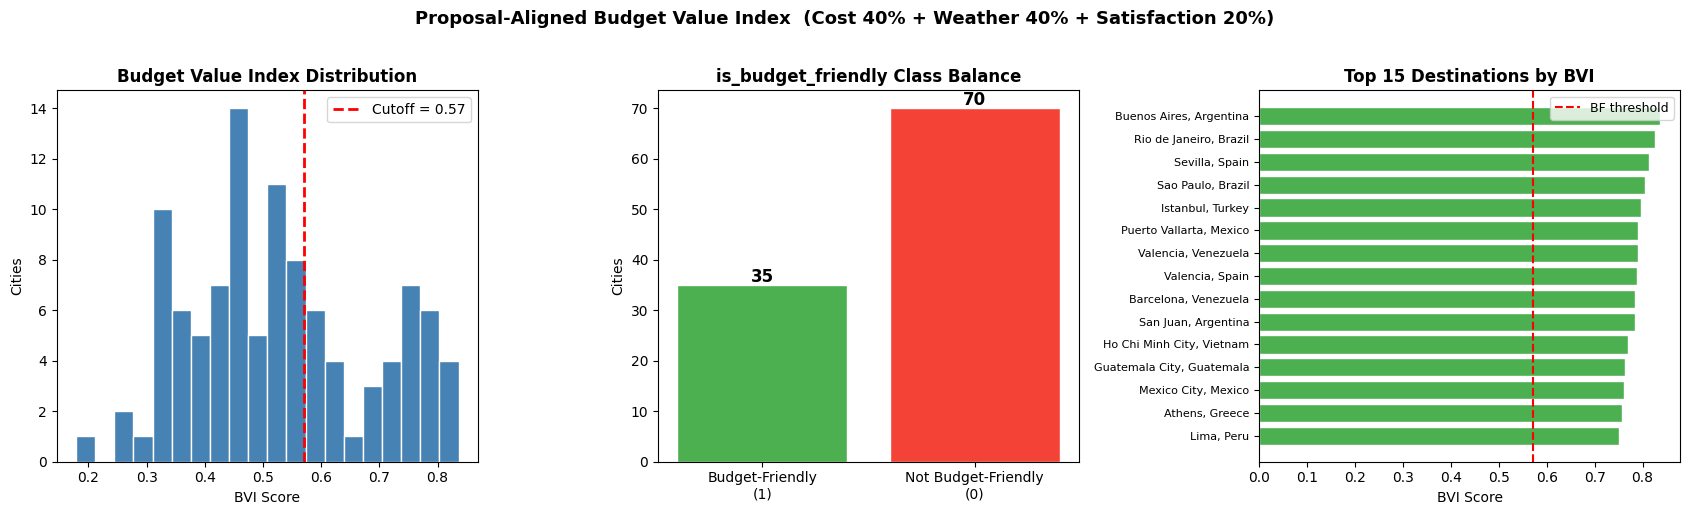

Saved: v3_budget_value_index.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

bvi = df['budget_value_index'].dropna()

# 3a: BVI histogram
axes[0].hist(bvi, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(cutoff, color='red', linestyle='--', lw=2, label=f'Cutoff = {cutoff:.2f}')
axes[0].set_title('Budget Value Index Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BVI Score')
axes[0].set_ylabel('Cities')
axes[0].legend()

# 3b: is_budget_friendly class balance
pos = int(np.nansum(df['is_budget_friendly']))
neg = int(df['is_budget_friendly'].notna().sum()) - pos
axes[1].bar(['Budget-Friendly\n(1)', 'Not Budget-Friendly\n(0)'],
            [pos, neg], color=['#4CAF50', '#F44336'], edgecolor='white')
for i, v in enumerate([pos, neg]):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('is_budget_friendly Class Balance', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cities')

# 3c: Top 15 cities by BVI
top15 = (df.dropna(subset=['budget_value_index'])
           .sort_values('budget_value_index', ascending=False).head(15))
colors_bar = ['#4CAF50' if v >= cutoff else '#2196F3'
               for v in top15['budget_value_index']]
axes[2].barh(top15['city'] + ', ' + top15['country'],
             top15['budget_value_index'], color=colors_bar, edgecolor='white')
axes[2].axvline(cutoff, color='red', linestyle='--', lw=1.5, label='BF threshold')
axes[2].invert_yaxis()
axes[2].set_title('Top 15 Destinations by BVI', fontsize=12, fontweight='bold')
axes[2].set_xlabel('BVI Score')
axes[2].legend(fontsize=9)
plt.setp(axes[2].get_yticklabels(), fontsize=8)

plt.suptitle('Proposal-Aligned Budget Value Index  (Cost 40% + Weather 40% + Satisfaction 20%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'v3_budget_value_index.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v3_budget_value_index.png')

#### **C.Feature Selection (variance → correlation → Random-Forest importance)**

Candidate matrix excludes IDs, derived labels, and **leakage** columns (the pieces that
build the target). Then a variance filter, a correlation filter (drop |r| > 0.85
duplicates), and **Random-Forest importance** toward both targets (regression on the index,
classification on `is_budget_friendly`) select the top features.

In [ ]:
ID_COLS = ["location_path", "city", "country", "airbnb_subregion", "city_key", "country_key",
           "currency", "geocode_source", "climate_zone"]
DERIVED_LABEL_COLS = ["cost_of_living_tier", "flight_price_tier"]
LEAKAGE_COLS = ["cost_of_living_composite", "avg_weather_score", "satisfaction_score",
                "satisfaction_0_1", "avg_overall_rating", "destination_value_score",
                "flight_price_est_usd"]
LEAKAGE_COLS += [c for c in df.columns if c.endswith(("_minmax", "_zscore"))]
EXCLUDE = set(ID_COLS + DERIVED_LABEL_COLS + LEAKAGE_COLS
              + ["budget_value_index", "is_budget_friendly", "in_ranking_pool"]
              + [c for c in df.columns if c.startswith("has_")])  # flags are descriptors, not features

candidates = [c for c in df.select_dtypes(include=[np.number, bool]).columns if c not in EXCLUDE]
X = df[candidates].astype(float)

# Variance threshold on standardized columns
Xs = pd.DataFrame(StandardScaler().fit_transform(X.fillna(X.median())), columns=X.columns)
vt = VarianceThreshold(0.01).fit(Xs)
dropped_variance = list(X.columns[~vt.get_support()])
Xv = X.loc[:, vt.get_support()]

# Correlation filter
corr = Xv.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
to_drop = [c for c in upper.columns if (upper[c] > 0.85).any()]
Xc = Xv.drop(columns=to_drop)
section("FEATURE SELECTION")
print(f"candidates={len(candidates)}  after variance={Xv.shape[1]}  after correlation={Xc.shape[1]}")
print("dropped (near-constant):", dropped_variance or "none")
print("dropped (correlated >0.85):", len(to_drop))

# Random-Forest importance toward both targets, on the labelled pool rows
lab = df["budget_value_index"].notna()
Xf = Xc.loc[lab].fillna(Xc.loc[lab].median()).fillna(0).replace([np.inf, -np.inf], 0)
rf_r = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3,
                             random_state=RANDOM_STATE).fit(Xf, df.loc[lab, "budget_value_index"])
rf_c = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=3,
                              random_state=RANDOM_STATE).fit(Xf, df.loc[lab, "is_budget_friendly"])
imp = pd.DataFrame({"regression": rf_r.feature_importances_,
                    "classification": rf_c.feature_importances_}, index=Xf.columns)
imp["avg"] = imp.mean(axis=1)
TOP_N = 12
selected = list(imp["avg"].sort_values(ascending=False).head(TOP_N).index)
print(f"\nTop {TOP_N} RF-selected features:")
print(imp.loc[selected, "avg"].round(4).to_string())


FEATURE SELECTION
candidates=45  after variance=45  after correlation=28
dropped (near-constant): none
dropped (correlated >0.85): 17

Top 12 RF-selected features:
cost_chicken_fillets_1kg    0.3394
avg_temp_c                  0.1643
dining_out_cost_index       0.0856
groceries_cost_index        0.0791
cost_imported_beer          0.0644
cost_milk_1l                0.0502
transport_cost_index        0.0451
avg_pct_sunny_days          0.0316
lat                         0.0276
cost_fastfood_combo_meal    0.0215
distance_from_lax_km        0.0143
avg_pct_pleasant_days       0.0135


**Correlation Heatmap BEFORE Selection**

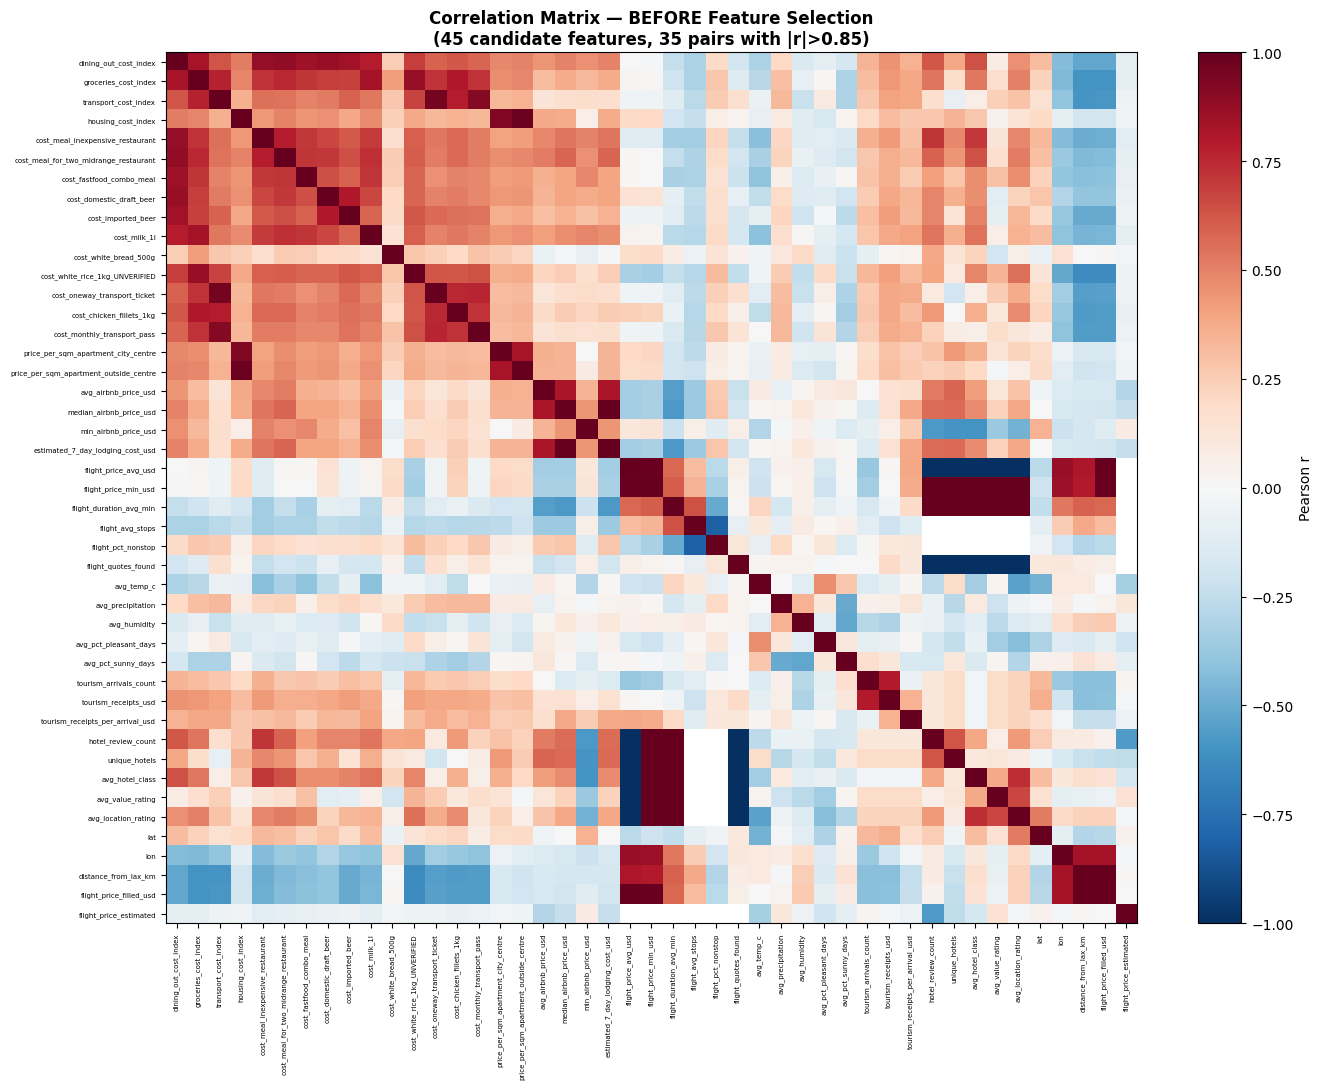

Saved: v5_corr_before.png  (35 highly-correlated pairs — confirms need for pruning)


In [ ]:
corr_before = X.corr()
upper_b = corr_before.where(np.triu(np.ones(corr_before.shape), k=1).astype(bool))
high_pairs = int((upper_b.abs() > 0.85).sum().sum())

plt.figure(figsize=(14, 11))
plt.imshow(corr_before.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Pearson r')
plt.xticks(range(len(corr_before.columns)), corr_before.columns, rotation=90, fontsize=5)
plt.yticks(range(len(corr_before.columns)), corr_before.columns, fontsize=5)
plt.title(f'Correlation Matrix — BEFORE Feature Selection\n({len(candidates)} candidate features, {high_pairs} pairs with |r|>0.85)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'v5_corr_before.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: v5_corr_before.png  ({high_pairs} highly-correlated pairs — confirms need for pruning)')

**Filter Method 1: Variance Threshold**

Removes near-constant columns (variance < 0.01 on standardised scale). These carry no predictive signal.

In [ ]:
Xs = pd.DataFrame(StandardScaler().fit_transform(X.fillna(X.median())), columns=X.columns)
vt = VarianceThreshold(0.01).fit(Xs)
dropped_variance = list(X.columns[~vt.get_support()])
Xv = X.loc[:, vt.get_support()]

print(f'Before : {X.shape[1]}  |  Dropped (near-constant): {len(dropped_variance)}  |  Remaining: {Xv.shape[1]}')
if dropped_variance: print(f'Dropped: {dropped_variance}')

Before : 45  |  Dropped (near-constant): 0  |  Remaining: 45


**Feature Variance (before & after threshold)**

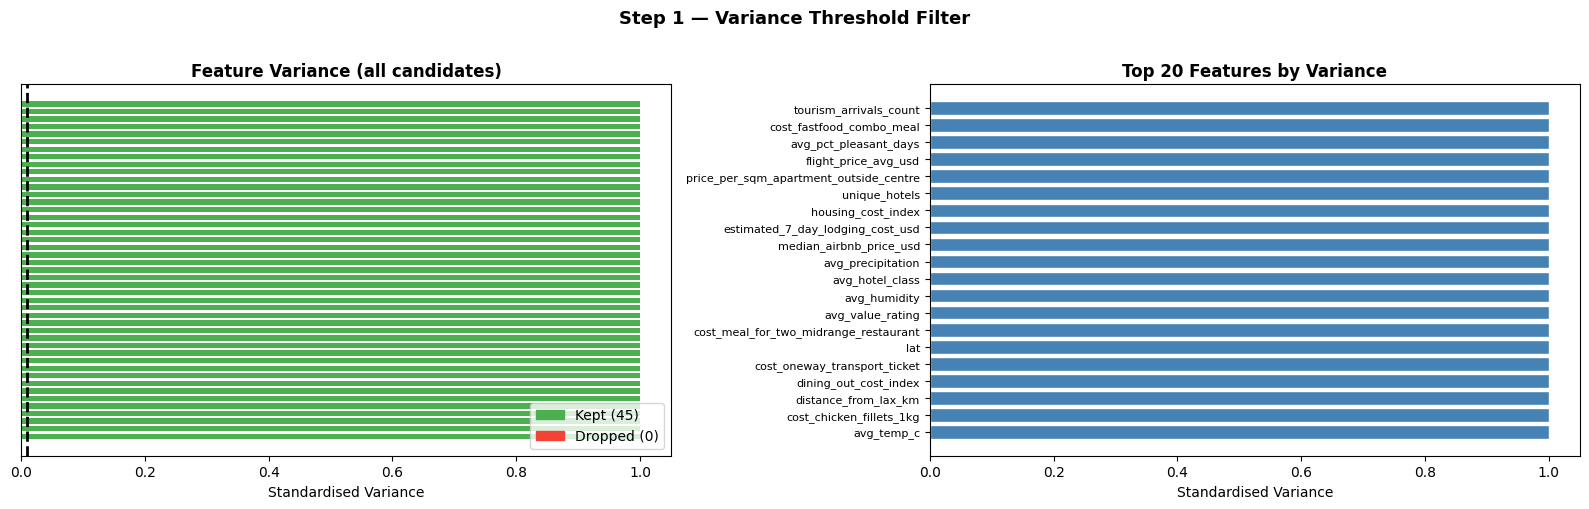

Saved: v6_variance_threshold.png


In [ ]:
variances = Xs.var().sort_values()
colors_var = ['#F44336' if c in dropped_variance else '#4CAF50' for c in variances.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(range(len(variances)), variances.values, color=colors_var, edgecolor='none', height=0.7)
axes[0].axvline(0.01, color='black', linestyle='--', lw=2, label='Threshold = 0.01')
axes[0].set_yticks([])
axes[0].set_xlabel('Standardised Variance')
axes[0].set_title('Feature Variance (all candidates)', fontsize=12, fontweight='bold')
axes[0].legend()
kept_patch   = mpatches.Patch(color='#4CAF50', label=f'Kept ({Xv.shape[1]})')
dropped_patch = mpatches.Patch(color='#F44336', label=f'Dropped ({len(dropped_variance)})')
axes[0].legend(handles=[kept_patch, dropped_patch], loc='lower right')

# Top-20 highest-variance features
top20 = variances.tail(20)
axes[1].barh(top20.index, top20.values, color='steelblue', edgecolor='white')
axes[1].set_title('Top 20 Features by Variance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Standardised Variance')
plt.setp(axes[1].get_yticklabels(), fontsize=8)

plt.suptitle('Step 1 — Variance Threshold Filter', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'v6_variance_threshold.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v6_variance_threshold.png')

**Filter Method 2: Pairwise Correlation Pruning (|r| > 0.85)**

In [ ]:
corr = Xv.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))

to_drop   = set()
drop_info = {}
for col in upper.columns:
    for row in upper.index:
        r = upper.loc[row, col]
        if pd.notna(r) and r > 0.85:
            # Prefer to keep composite/index, drop scaled duplicates and raw line items
            candidates_pair = sorted([row, col], key=lambda c: (
                c.endswith(('_minmax', '_zscore')),
                'composite' not in c and '_index' not in c,
                len(c)
            ))
            victim = candidates_pair[-1]
            if victim not in to_drop:
                to_drop.add(victim)
                drop_info[victim] = f'r={r:.2f} with "{row if victim == col else col}"'

Xc = Xv.drop(columns=list(to_drop))
print(f'After variance: {Xv.shape[1]}  |  Dropped (correlated >0.85): {len(to_drop)}  |  Remaining: {Xc.shape[1]}')

After variance: 45  |  Dropped (correlated >0.85): 15  |  Remaining: 30


**Embedded Method: Random Forest Feature Importance**

In [ ]:
lab  = df['budget_value_index'].notna()
Xf   = Xc.loc[lab].fillna(Xc.loc[lab].median()).fillna(0).replace([np.inf, -np.inf], 0)
y_r  = df.loc[lab, 'budget_value_index']
y_c  = df.loc[lab, 'is_budget_friendly']

rf_r = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=3,
                              random_state=RANDOM_STATE).fit(Xf, y_r)
rf_c = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=3,
                               random_state=RANDOM_STATE).fit(Xf, y_c)

imp = pd.DataFrame({'regression': rf_r.feature_importances_,
                    'classification': rf_c.feature_importances_}, index=Xf.columns)
imp['avg'] = imp.mean(axis=1)
TOP_N    = 12
selected = list(imp['avg'].sort_values(ascending=False).head(TOP_N).index)

print(f'Top {TOP_N} RF-selected features:')
print(imp.loc[selected].round(4).to_string())

Top 12 RF-selected features:
                          regression  classification     avg
cost_chicken_fillets_1kg      0.5448          0.1232  0.3340
avg_temp_c                    0.2117          0.1051  0.1584
dining_out_cost_index         0.0471          0.1403  0.0937
groceries_cost_index          0.0427          0.1232  0.0830
cost_imported_beer            0.0401          0.0946  0.0674
cost_milk_1l                  0.0107          0.0727  0.0417
transport_cost_index          0.0084          0.0745  0.0414
avg_pct_sunny_days            0.0386          0.0313  0.0349
lat                           0.0066          0.0427  0.0247
cost_fastfood_combo_meal      0.0114          0.0331  0.0223
avg_pct_pleasant_days         0.0067          0.0248  0.0157
distance_from_lax_km          0.0047          0.0205  0.0126


**Random Forest Feature Importance**


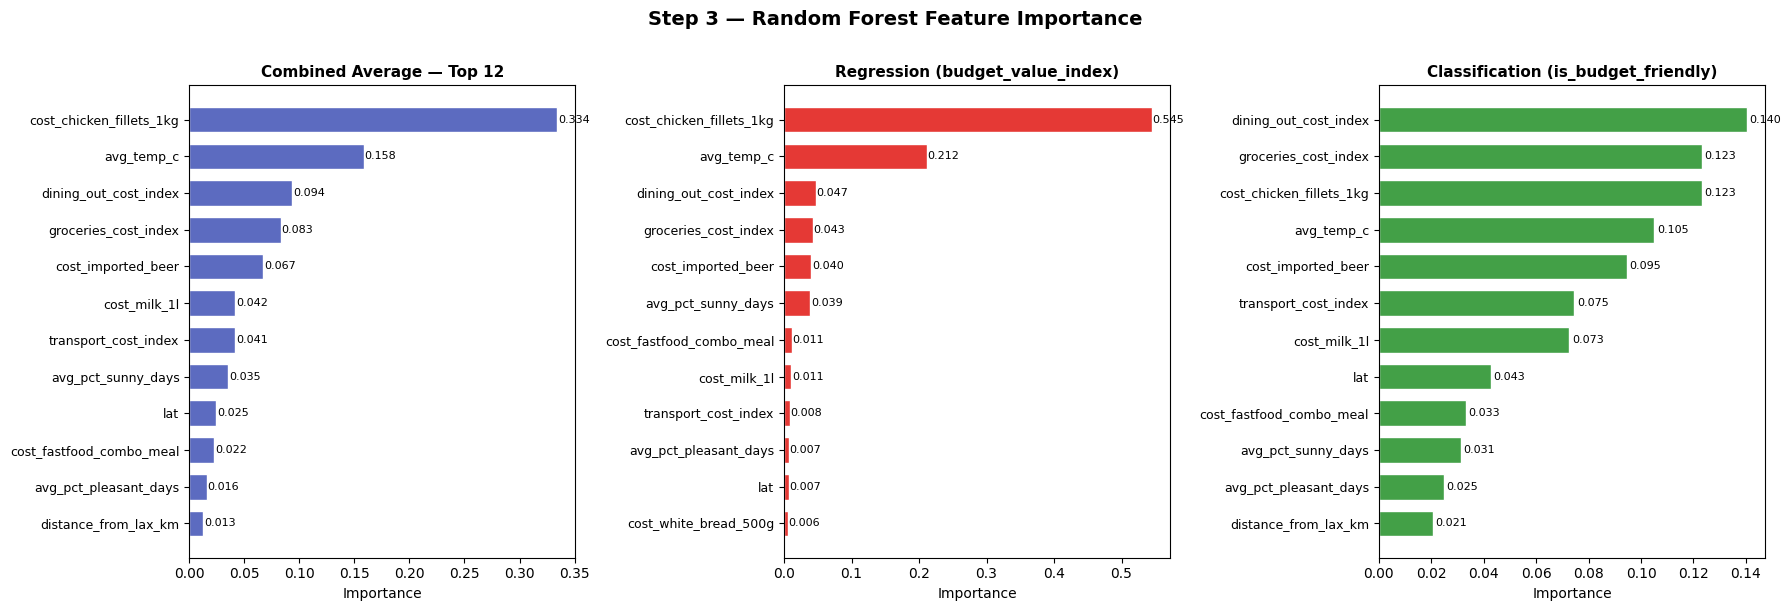

Saved: v7_rf_importance.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, color, title in [
    (axes[0], 'avg',            '#5C6BC0', f'Combined Average — Top {TOP_N}'),
    (axes[1], 'regression',     '#E53935', 'Regression (budget_value_index)'),
    (axes[2], 'classification', '#43A047', 'Classification (is_budget_friendly)'),
]:
    top = imp[col].sort_values(ascending=False).head(TOP_N).iloc[::-1]
    bars = ax.barh(top.index, top.values, color=color, edgecolor='white', height=0.7)
    for bar in bars:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.setp(ax.get_yticklabels(), fontsize=9)

plt.suptitle('Step 3 — Random Forest Feature Importance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'v7_rf_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v7_rf_importance.png')

#### **D. Feature Extraction (PCA) on the correlated cost and review blocks**

In [ ]:
COST_BLOCK = ["dining_out_cost_index", "groceries_cost_index", "transport_cost_index",
              "housing_cost_index", "cost_meal_inexpensive_restaurant",
              "cost_meal_for_two_midrange_restaurant", "cost_fastfood_combo_meal",
              "cost_domestic_draft_beer", "cost_imported_beer", "cost_milk_1l",
              "cost_white_bread_500g", "cost_white_rice_1kg_UNVERIFIED",
              "cost_oneway_transport_ticket", "cost_chicken_fillets_1kg",
              "cost_monthly_transport_pass", "price_per_sqm_apartment_city_centre",
              "price_per_sqm_apartment_outside_centre"]
REVIEW_BLOCK = ["avg_service_rating", "avg_cleanliness_rating", "avg_value_rating", "avg_location_rating"]


def run_pca_block(cols, name, var_target=0.85, max_comp=5):
    avail = [c for c in cols if c in df.columns]
    if not avail:
        return pd.DataFrame(index=df.index)
    block = df[avail].astype(float).fillna(df[avail].astype(float).median())
    scaled = StandardScaler().fit_transform(np.log1p(block.clip(lower=0)))
    full = PCA(random_state=RANDOM_STATE).fit(scaled)
    n = int(np.searchsorted(np.cumsum(full.explained_variance_ratio_), var_target) + 1)
    n = min(max(n, 1), max_comp, len(avail))
    comps = PCA(n_components=n, random_state=RANDOM_STATE).fit_transform(scaled)
    return pd.DataFrame(comps, columns=[f"{name}_pc{i+1}" for i in range(n)], index=df.index)


cost_pcs = run_pca_block(COST_BLOCK, "cost")
review_pcs = run_pca_block(REVIEW_BLOCK, "review")
section("PCA")
print("cost components:", list(cost_pcs.columns), "| review components:", list(review_pcs.columns))
# avoid double-counting: if a selected feature is part of a PCA block, drop it from selected
pca_members = set(COST_BLOCK + REVIEW_BLOCK)
final_features = [c for c in selected if c not in pca_members]
print("RF features kept (excluding PCA-block members):", final_features)


PCA
cost components: ['cost_pc1', 'cost_pc2', 'cost_pc3', 'cost_pc4', 'cost_pc5'] | review components: ['review_pc1', 'review_pc2']
RF features kept (excluding PCA-block members): ['avg_temp_c', 'avg_pct_sunny_days', 'lat', 'avg_pct_pleasant_days', 'distance_from_lax_km']


In [ ]:
# ── Guard: recompute PCA if runtime was reset ───────────────────────────────
if 'cost_pcs' not in dir() or cost_pcs is None:
    print('PCA variables missing — recomputing (run Section 6 cell first next time)...')
    cost_pcs,   cost_pca,   cost_cumvar,   avail_cost   = run_pca_block(COST_BLOCK,   'cost')
    review_pcs, review_pca, review_cumvar, avail_review = run_pca_block(REVIEW_BLOCK, 'review', max_comp=2)
    pca_members = set(COST_BLOCK + REVIEW_BLOCK)

#### **E.Assemble the model-ready dataset (with the descriptor "contract" kept)**

The output keeps the descriptor columns the Modeling phase needs (cost, weather, coverage
flags, geo features), the two targets, the RF-selected features, and the PCA components.

In [ ]:
DESCRIPTORS = ["cost_of_living_composite", "avg_weather_score", "satisfaction_score",
               "has_cost_of_living", "has_weather_data", "has_flight_data", "has_airbnb_data",
               "has_hotel_review_data", "lat", "lon", "distance_from_lax_km",
               "flight_price_filled_usd", "flight_price_estimated", "climate_zone", "in_ranking_pool"]
id_keep = [c for c in ["city", "country", "city_key", "country_key", "airbnb_subregion"] if c in df.columns]
desc_keep = [c for c in DESCRIPTORS if c in df.columns]
base_cols = id_keep + desc_keep + ["budget_value_index", "is_budget_friendly"]
sel_unique = [c for c in final_features if c not in set(base_cols)]  # avoid duplicate columns

model_ready = pd.concat([df[base_cols + sel_unique], cost_pcs, review_pcs], axis=1)
out_path = os.path.join(OUTPUT_DIR, "model_ready_dataset.csv")
model_ready.to_csv(out_path, index=False)
section("MODEL-READY DATASET")
print("shape:", model_ready.shape)
print("columns:", list(model_ready.columns))
print("saved ->", out_path)


MODEL-READY DATASET
shape: (4999, 32)
columns: ['city', 'country', 'city_key', 'country_key', 'airbnb_subregion', 'cost_of_living_composite', 'avg_weather_score', 'satisfaction_score', 'has_cost_of_living', 'has_weather_data', 'has_flight_data', 'has_airbnb_data', 'has_hotel_review_data', 'lat', 'lon', 'distance_from_lax_km', 'flight_price_filled_usd', 'flight_price_estimated', 'climate_zone', 'in_ranking_pool', 'budget_value_index', 'is_budget_friendly', 'avg_temp_c', 'avg_pct_sunny_days', 'avg_pct_pleasant_days', 'cost_pc1', 'cost_pc2', 'cost_pc3', 'cost_pc4', 'cost_pc5', 'review_pc1', 'review_pc2']
saved -> /content/drive/MyDrive/COMP541 - Group 1/Prepped Data Files (for merging)/alternate integration output/model_ready_dataset.csv


**Correlation Heatmap AFTER Selection**

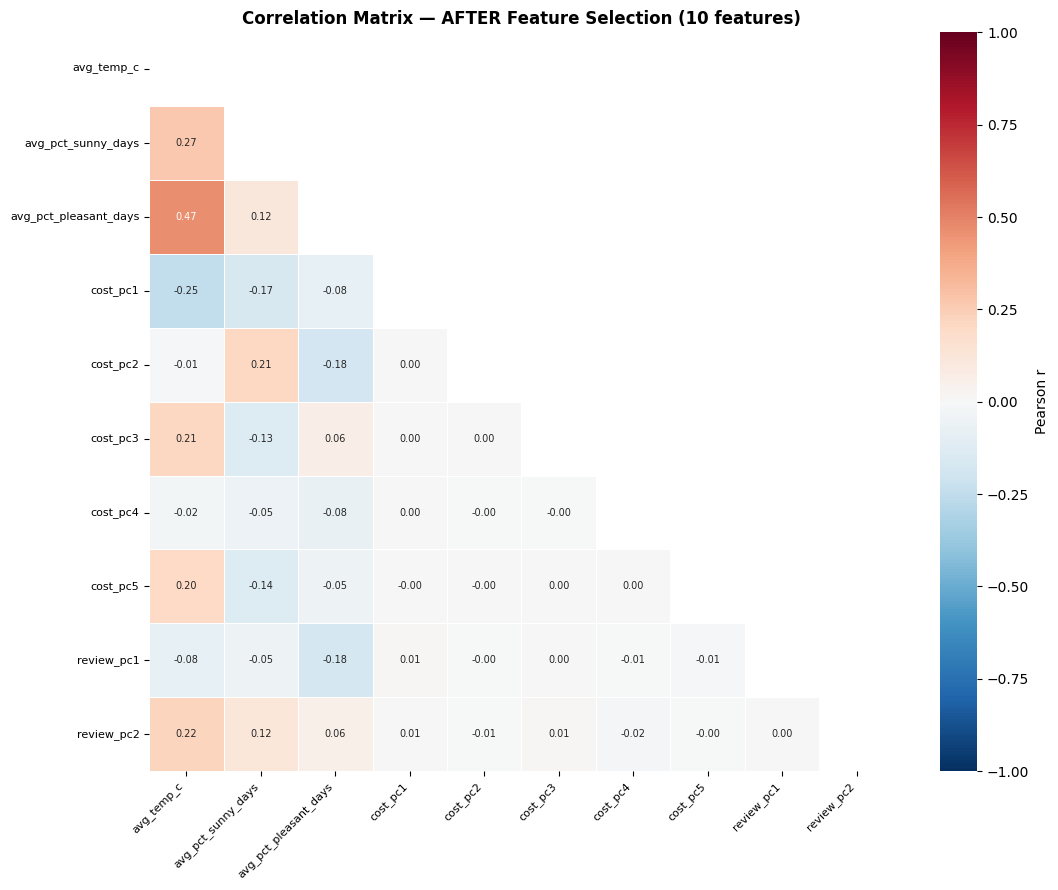

Saved: v9_corr_after.png


In [ ]:
feat_cols = [c for c in model_ready.columns
             if c not in set(id_keep + desc_keep + ['budget_value_index', 'is_budget_friendly',
                                                     'climate_zone', 'geocode_source'])]
feat_cols = [c for c in feat_cols if model_ready[c].dtype in [np.float64, np.int64, float, int]]

plt.figure(figsize=(11, 9))
corr_after = model_ready[feat_cols].corr()
mask = np.zeros_like(corr_after, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_after, mask=mask, cmap='RdBu_r', vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, square=False, cbar_kws={'label': 'Pearson r'})
plt.title(f'Correlation Matrix — AFTER Feature Selection ({len(feat_cols)} features)',
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'v9_corr_after.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: v9_corr_after.png')

#### **F. Feature-selection audit trail**

In [ ]:
rows = []
for c in candidates:
    if c in dropped_variance:
        d, why = "dropped", "near-zero variance"
    elif c in to_drop:
        d, why = "dropped", "correlated duplicate (>0.85)"
    elif c in pca_members:
        d, why = "replaced by PCA", "member of correlated block"
    elif c in final_features:
        d, why = "kept", f"top {TOP_N} RF importance"
    else:
        d, why = "dropped", "below importance cutoff"
    rows.append({"column": c, "decision": d, "reason": why})
audit = pd.DataFrame(rows)
audit_path = os.path.join(OUTPUT_DIR, "feature_selection_report.csv")
audit.to_csv(audit_path, index=False)
section("AUDIT TRAIL")
print(audit["decision"].value_counts().to_string())
print("saved ->", audit_path)


AUDIT TRAIL
decision
dropped            30
replaced by PCA    10
kept                5
saved -> /content/drive/MyDrive/COMP541 - Group 1/Prepped Data Files (for merging)/alternate integration output/feature_selection_report.csv


#### **Feature Selection Visualizations**

**Imputations**

In [ ]:
# ── alias: Part-2 uses 'audit', Part-3 visuals expect 'feature_report' ──────
feature_report = audit.copy()

# ── Column detection (used by the new visuals below) ─────────────────────────
city_col            = first_existing(model_ready, ["city", "City"])
country_col         = first_existing(model_ready, ["country", "Country"])
budget_value_col    = first_existing(model_ready, ["budget_value_index"])
budget_friendly_col = first_existing(model_ready, ["is_budget_friendly"])
cost_col            = first_existing(model_ready, ["cost_of_living_composite", "cost_composite"])
weather_col         = first_existing(model_ready, ["avg_weather_score", "weather_score"])
satisfaction_col    = first_existing(model_ready, ["satisfaction_score", "avg_satisfaction_score"])
flight_col          = first_existing(model_ready, ["flight_price_filled_usd", "flight_price_est_usd"])

# ── Build viz_df with normalised scores ──────────────────────────────────────
viz_df = model_ready.copy()

if cost_col:
    viz_df["Affordability Score"] = minmax_score(viz_df[cost_col], higher_is_better=False)
else:
    viz_df["Affordability Score"] = 0.5

if weather_col:
    viz_df["Weather Score Scaled"] = minmax_score(viz_df[weather_col], higher_is_better=True)
else:
    viz_df["Weather Score Scaled"] = 0.5

if satisfaction_col:
    viz_df["Satisfaction Score Scaled"] = minmax_score(viz_df[satisfaction_col], higher_is_better=True)
else:
    viz_df["Satisfaction Score Scaled"] = 0.5

viz_df["Enjoyment Score"] = viz_df[["Weather Score Scaled", "Satisfaction Score Scaled"]].mean(axis=1)

if budget_value_col:
    viz_df["Budget Value for Visuals"] = pd.to_numeric(viz_df[budget_value_col], errors="coerce")
else:
    viz_df["Budget Value for Visuals"] = (
        0.40 * viz_df["Affordability Score"] +
        0.40 * viz_df["Weather Score Scaled"] +
        0.20 * viz_df["Satisfaction Score Scaled"]
    )

print("Visual bridge ready ✓")
print(f"  feature_report rows : {len(feature_report)}")
print(f"  viz_df rows         : {len(viz_df)}")
print(f"  budget_value_col    : {budget_value_col}")
print(f"  budget_friendly_col : {budget_friendly_col}")

Visual bridge ready ✓
  feature_report rows : 45
  viz_df rows         : 4999
  budget_value_col    : budget_value_index
  budget_friendly_col : is_budget_friendly


**Feature Selection Decisions**

How many features were kept, dropped, or replaced by PCA.

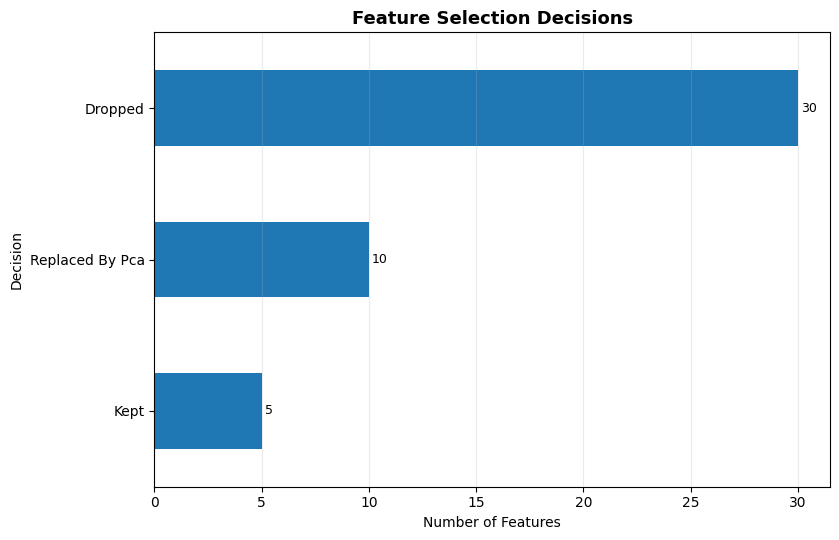

Saved: v10_feature_decisions.png


In [ ]:
if "decision" in feature_report.columns:
    decision_counts = (
        feature_report["decision"]
        .fillna("unknown")
        .map(clean_label)
        .value_counts()
        .sort_values(ascending=True)
    )
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    decision_counts.plot(kind="barh", ax=ax)
    ax.set_title("Feature Selection Decisions", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("Decision")
    ax.grid(axis="x", alpha=0.25)
    add_bar_labels(ax, orientation="horizontal", fmt="{:.0f}")
    plt.tight_layout()
    plt.show()                                      # ← show first
    fig.savefig(os.path.join(CHART_DIR, "v10_feature_decisions.png"),
                dpi=150, bbox_inches="tight")       # ← then save
    plt.close(fig)
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")
    ax.set_title("Feature Selection Decisions", fontsize=15, fontweight="bold")
    ax.text(0.5, 0.5, "feature_report does not contain a decision column.",
            ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(CHART_DIR, "v10_feature_decisions.png"),
                dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Saved: v10_feature_decisions.png")

**Feature Selection Reasons**

Why each feature was kept, dropped, or replaced.

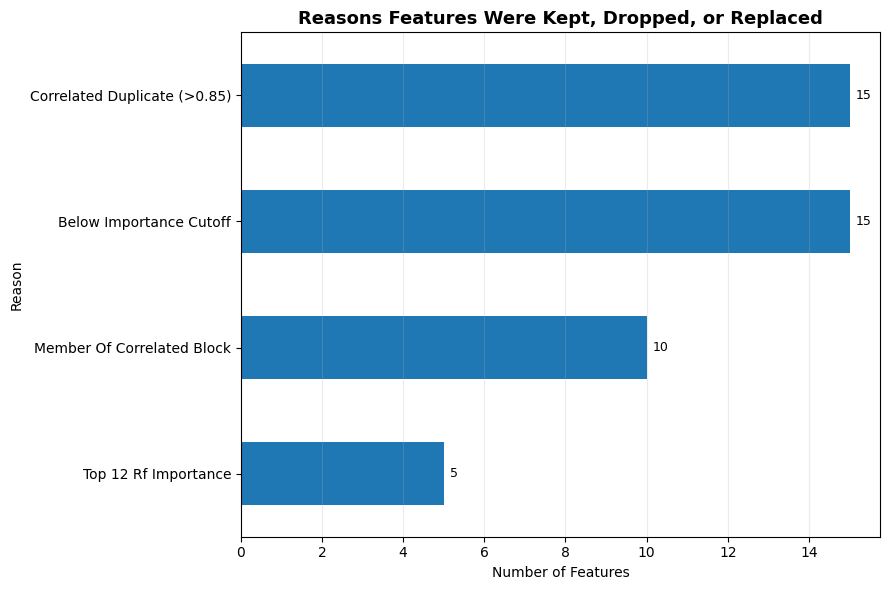

Saved: v11_feature_reasons.png


In [ ]:
if "reason" in feature_report.columns:
    reason_counts = (
        feature_report["reason"]
        .fillna("unknown")
        .str.split("  ", expand=True)[0]
        .map(clean_label)
        .value_counts()
        .sort_values(ascending=True)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    reason_counts.plot(kind="barh", ax=ax)
    ax.set_title("Reasons Features Were Kept, Dropped, or Replaced", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("Reason")
    ax.grid(axis="x", alpha=0.25)
    add_bar_labels(ax, orientation="horizontal", fmt="{:.0f}")
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(CHART_DIR, "v11_feature_reasons.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
else:
    make_text_visual(
        "Feature Selection Reasons",
        "Feature selection report does not contain a reason column.",
        "v11_feature_reasons.png"
    )
print("Saved: v11_feature_reasons.png")

**Model-Ready Column Roles**

Structure of the final model-ready dataset by column role.

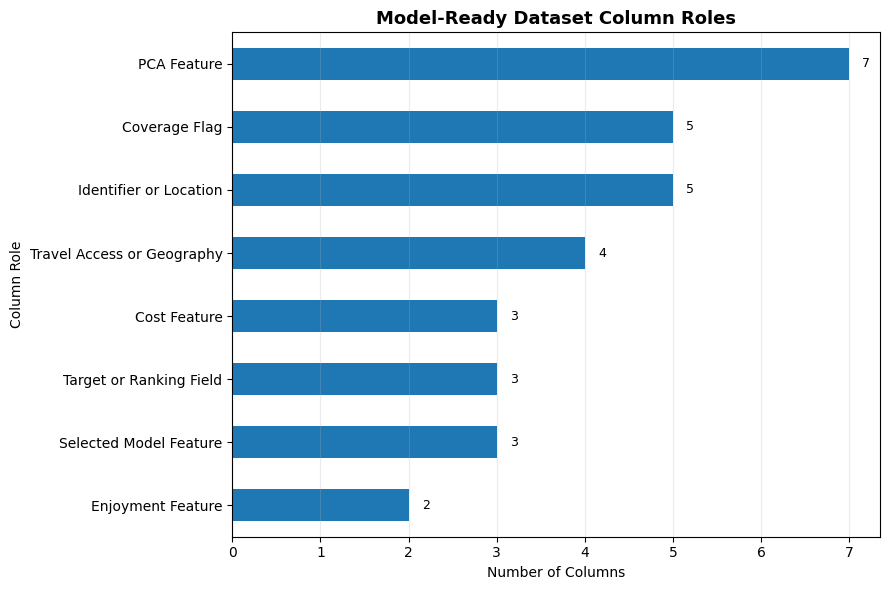

Saved: v12_column_roles.png


In [ ]:
def classify_column_role(col):
    lower = col.lower()
    identifiers = {"city", "country", "city_key", "country_key", "airbnb_subregion", "subregion", "region"}
    targets     = {"budget_value_index", "is_budget_friendly", "in_ranking_pool"}
    if lower in identifiers:          return "Identifier or Location"
    if lower in targets:              return "Target or Ranking Field"
    if lower.startswith("has_"):      return "Coverage Flag"
    if lower.startswith("cost_pc") or lower.startswith("review_pc"): return "PCA Feature"
    if any(t in lower for t in ["cost","meal","beer","milk","bread","rice","grocery","transport","apartment","rent"]):
        return "Cost Feature"
    if any(t in lower for t in ["weather","satisfaction","rating","review","enjoyment"]):
        return "Enjoyment Feature"
    if any(t in lower for t in ["flight","distance","lat","lon","climate"]):
        return "Travel Access or Geography"
    return "Selected Model Feature"

role_counts = (
    pd.Series([classify_column_role(c) for c in model_ready.columns])
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
role_counts.plot(kind="barh", ax=ax)
ax.set_title("Model-Ready Dataset Column Roles", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Columns")
ax.set_ylabel("Column Role")
ax.grid(axis="x", alpha=0.25)
add_bar_labels(ax, orientation="horizontal", fmt="{:.0f}")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(CHART_DIR, "v12_column_roles.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved: v12_column_roles.png")

**Budget Value Index Distribution**

Histogram of the BVI target across all destinations.

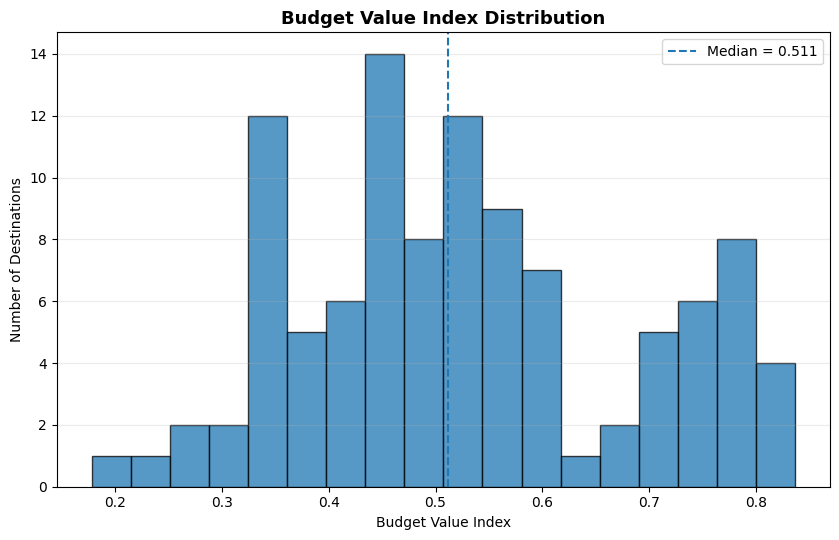

Saved: v13_bvi_distribution.png


In [ ]:
if budget_value_col is not None:
    values = pd.to_numeric(viz_df[budget_value_col], errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.hist(values, bins=18, edgecolor="black", alpha=0.75)
    ax.axvline(values.median(), linestyle="--", linewidth=1.5,
               label=f"Median = {values.median():.3f}")
    ax.set_title("Budget Value Index Distribution", fontsize=13, fontweight="bold")
    ax.set_xlabel("Budget Value Index")
    ax.set_ylabel("Number of Destinations")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(CHART_DIR, "v13_bvi_distribution.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis("off")
    ax.set_title("Budget Value Distribution", fontsize=15, fontweight="bold")
    ax.text(0.5, 0.5, "No budget_value_index column found.",
            ha="center", va="center", fontsize=12)
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(CHART_DIR, "v13_bvi_distribution.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Saved: v13_bvi_distribution.png")

**Budget-Friendly Target Split**

Class balance of the binary classification target.

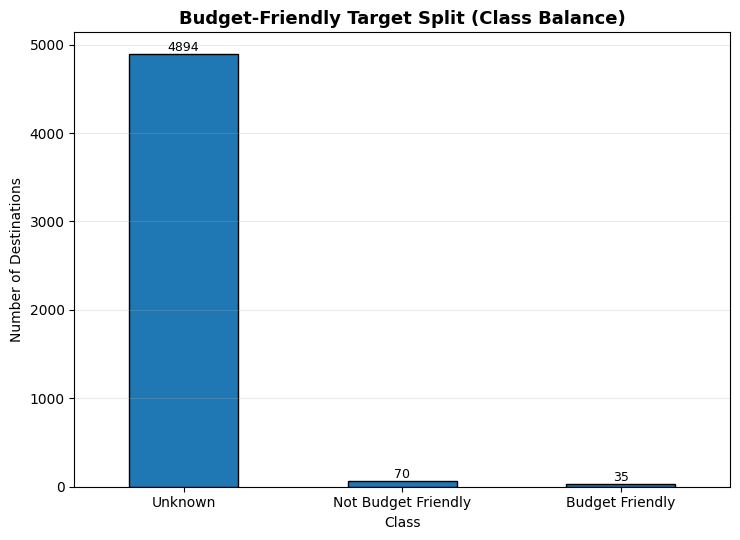

Saved: v14_target_split.png


In [ ]:

if budget_friendly_col is not None:
    target_counts = (
        pd.to_numeric(viz_df[budget_friendly_col], errors="coerce")
        .map({0: "Not Budget Friendly", 1: "Budget Friendly"})
        .fillna("Unknown")
        .value_counts()
    )
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    target_counts.plot(kind="bar", ax=ax, edgecolor="black")
    ax.set_title("Budget-Friendly Target Split (Class Balance)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of Destinations")
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=0)
    add_bar_labels(ax, orientation="vertical", fmt="{:.0f}")
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(CHART_DIR, "v14_target_split.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
else:
    print("No is_budget_friendly column found")
print("Saved: v14_target_split.png")


**Cost & Enjoyment Map**

Engineered feature space: affordability vs enjoyment (weather + satisfaction).

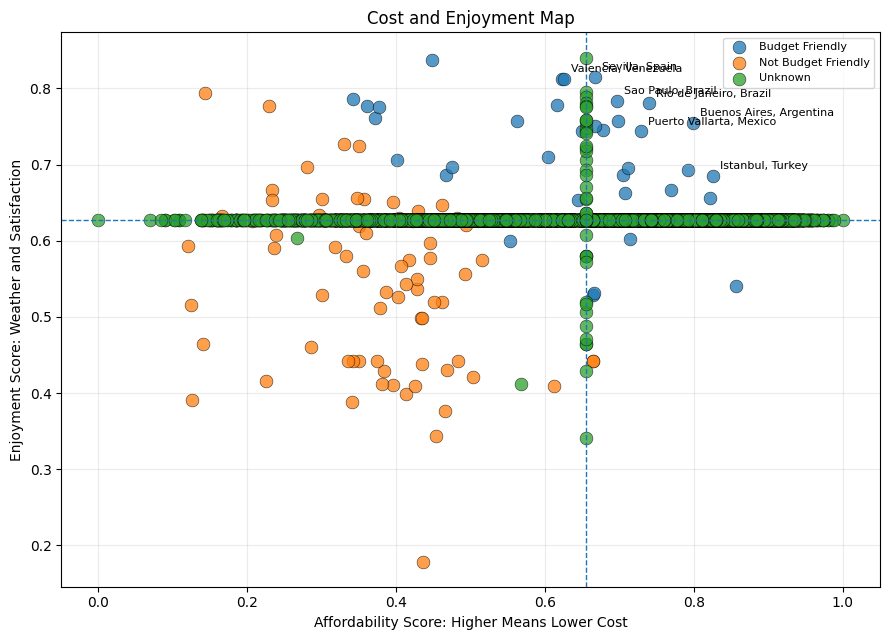

Saved: v15_cost_enjoyment_map.png


In [ ]:

fig, ax = plt.subplots(figsize=(9, 6.5))

if budget_friendly_col is not None:
    plot_df = viz_df.copy()
    plot_df["Budget Friendly Label"] = (
        pd.to_numeric(plot_df[budget_friendly_col], errors="coerce")
        .map({0: "Not Budget Friendly", 1: "Budget Friendly"})
        .fillna("Unknown")
    )
    for label, group in plot_df.groupby("Budget Friendly Label"):
        ax.scatter(
            group["Affordability Score"],
            group["Enjoyment Score"],
            s=85, alpha=0.75, edgecolors="black", linewidths=0.4, label=label
        )
else:
    plot_df = viz_df.copy()
    ax.scatter(
        plot_df["Affordability Score"],
        plot_df["Enjoyment Score"],
        s=85, alpha=0.75, edgecolors="black", linewidths=0.4
    )

ax.axvline(plot_df["Affordability Score"].median(), linestyle="--", linewidth=1)
ax.axhline(plot_df["Enjoyment Score"].median(), linestyle="--", linewidth=1)

if city_col is not None and country_col is not None:
    label_df = plot_df.sort_values("Budget Value for Visuals", ascending=False).head(7)
    for _, row in label_df.iterrows():
        ax.annotate(
            f"{row[city_col]}, {row[country_col]}",
            (row["Affordability Score"], row["Enjoyment Score"]),
            xytext=(5, 5), textcoords="offset points", fontsize=8
        )

ax.set_title("Cost and Enjoyment Map")
ax.set_xlabel("Affordability Score: Higher Means Lower Cost")
ax.set_ylabel("Enjoyment Score: Weather and Satisfaction")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()
fig.savefig(os.path.join(CHART_DIR, "v15_cost_enjoyment_map.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved: v15_cost_enjoyment_map.png")


**Cost PCA Space**

Destinations projected onto the first two cost PCA components.

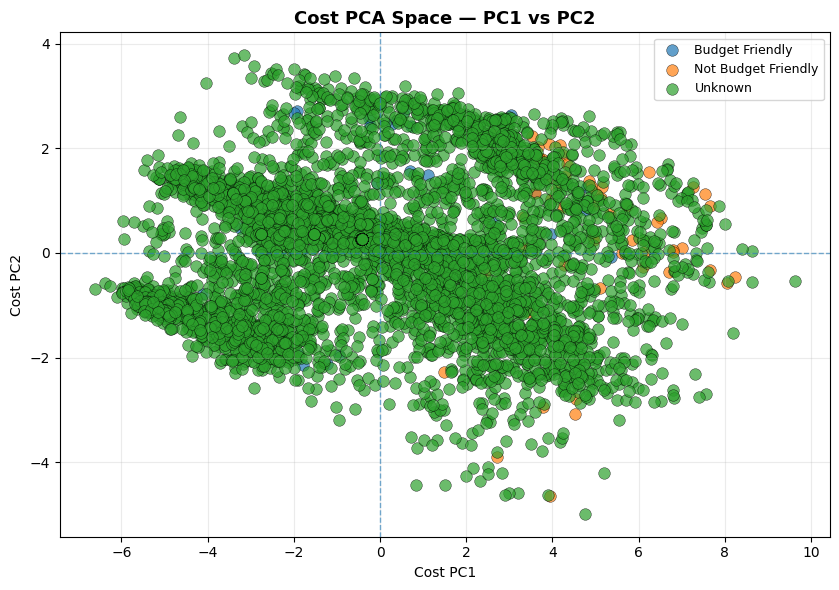

Saved: v16_cost_pca_space.png


In [ ]:

cost_pc1 = first_existing(model_ready, ["cost_pc1", "Cost PC1"])
cost_pc2 = first_existing(model_ready, ["cost_pc2", "Cost PC2"])

if cost_pc1 and cost_pc2:
    pca_df = model_ready.copy()
    if budget_friendly_col:
        pca_df["Budget Friendly Label"] = (
            pd.to_numeric(pca_df[budget_friendly_col], errors="coerce")
            .map({0: "Not Budget Friendly", 1: "Budget Friendly"})
            .fillna("Unknown")
        )
    else:
        pca_df["Budget Friendly Label"] = "Destination"

    fig, ax = plt.subplots(figsize=(8.5, 6))
    for label, group in pca_df.groupby("Budget Friendly Label"):
        ax.scatter(
            pd.to_numeric(group[cost_pc1], errors="coerce"),
            pd.to_numeric(group[cost_pc2], errors="coerce"),
            s=70, alpha=0.70, edgecolors="black", linewidths=0.35, label=label
        )
    ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.axvline(0, linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title("Cost PCA Space — PC1 vs PC2", fontsize=13, fontweight="bold")
    ax.set_xlabel("Cost PC1")
    ax.set_ylabel("Cost PC2")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    fig.savefig(os.path.join(CHART_DIR, "v16_cost_pca_space.png"), dpi=150, bbox_inches="tight")
    plt.close(fig)
else:
    print("⚠️  cost_pc1 / cost_pc2 columns not found in model_ready")
print("Saved: v16_cost_pca_space.png")


#### **Summary**

The Budget Value Index is cost + satisfaction + weather on the ~105-city pool (clearing "≥50"),
the flight/geo features are created, and the output retains
the descriptor columns the Modeling phase needs. Outputs: `model_ready_dataset.csv` and
`feature_selection_report.csv`.